# FYP Continual Learning Experiment

This notebook imports reusable logic from the Python scripts and runs the experiment interactively.

In [16]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "hybrid_pipeline").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from hybrid_pipeline.core_pipeline import CONFIG, configure_vast_ai, prepare_data, print_task_summary
from hybrid_pipeline.experiment_runner import run_experiment, build_cl_summary, build_fwt_details, build_forgetting_details, print_and_save_comparison_tables, generate_all_plots


## Vast.ai / GPU setup

On Vast.ai, upload the project folder to a location such as `/workspace/fyp`. Put the CSV files in `/workspace/fyp/data/processed`, then set `data_dir` below. For local runs, leave both values as `None`.

In [18]:
DATA_DIR = str(PROJECT_ROOT / "data" / "processed")
OUTPUT_DIR = str(PROJECT_ROOT / "outputs" / "hybrid")

configure_vast_ai(DATA_DIR, OUTPUT_DIR, require_gpu=False)



Runtime diagnostics
  Python         : 3.11.9
  PyTorch        : 2.3.1+cpu
  CUDA available : False
  CPU cores      : 12
  Vast.ai        : NO
  Active device  : CPU
  Precision      : 32


{'paths': {'demand_csv': 'C:\\Users\\Syakir\\Downloads\\Projects\\fyp\\data\\processed\\demand_forecasting.csv',
  'rl_csv': 'C:\\Users\\Syakir\\Downloads\\Projects\\fyp\\data\\processed\\rl_environment.csv',
  'checkpoints': 'C:\\Users\\Syakir\\Downloads\\Projects\\fyp\\outputs\\hybrid\\checkpoints',
  'results': 'C:\\Users\\Syakir\\Downloads\\Projects\\fyp\\outputs\\hybrid\\results',
  'logs': 'C:\\Users\\Syakir\\Downloads\\Projects\\fyp\\outputs\\hybrid\\logs',
  'plots': 'C:\\Users\\Syakir\\Downloads\\Projects\\fyp\\outputs\\hybrid\\plots'},
 'tasks': [{'task_id': 1,
   'name': 'Baseline_2023_H1',
   'start': '2023-01-01',
   'end': '2023-05-31',
   'regime': 'baseline'},
  {'task_id': 2,
   'name': 'MegaSale_2023',
   'start': '2023-06-01',
   'end': '2023-12-31',
   'regime': 'mega_sale'},
  {'task_id': 3,
   'name': 'Baseline_2024_H1',
   'start': '2024-01-01',
   'end': '2024-05-31',
   'regime': 'baseline'},
  {'task_id': 4,
   'name': 'MegaSale_2024',
   'start': '2024-06-01'

In [19]:
tft_tasks, rl_tasks, tft_df, rl_df = prepare_data()
print_task_summary(tft_tasks, rl_tasks)


Loading datasets...
  Demand CSV  : 9,864 rows × 24 cols
  RL CSV      : 9,864 rows × 19 cols
✓ Data loaded and cleaned
┌──────┬──────────────────┬──────────────────────────┬──────────┬─────────┐
│ Task │ Name             │ Period                   │ TFT rows │ RL rows │
├──────┼──────────────────┼──────────────────────────┼──────────┼─────────┤
│ 1    │ Baseline_2023_H1 │ 2023-01-01 -> 2023-05-31 │ 1,359    │ 1,359   │
│ 2    │ MegaSale_2023    │ 2023-06-01 -> 2023-12-31 │ 1,926    │ 1,926   │
│ 3    │ Baseline_2024_H1 │ 2024-01-01 -> 2024-05-31 │ 1,368    │ 1,368   │
│ 4    │ MegaSale_2024    │ 2024-06-01 -> 2024-12-31 │ 1,926    │ 1,926   │
│ 5    │ Baseline_2025_H1 │ 2025-01-01 -> 2025-05-31 │ 1,359    │ 1,359   │
│ 6    │ MegaSale_2025    │ 2025-06-01 -> 2025-12-31 │ 1,926    │ 1,926   │
└──────┴──────────────────┴──────────────────────────┴──────────┴─────────┘


In [20]:
from hybrid_pipeline.core_pipeline import CONFIG

CONFIG["hardware"]["compile"] = False
print(CONFIG["hardware"]["compile"])

False


In [21]:
run_experiment(tft_tasks, rl_tasks)



  CONTINUAL LEARNING EXPERIMENT START

═══ MODEL TYPE: FORECASTING ═══

  ── CL Method: naive ──

  Task 1/6: Baseline_2023_H1


  ✓ Training complete
  Evaluating on 1 seen task(s)...
    Eval task 1: mase=0.6690  smape=59.5494  rmse=335.4438
  Evaluating on 5 future task(s) for FWT...
    Future eval task 2: mase=1.7900  smape=109.4019  rmse=693.3179
    Future eval task 3: mase=1.1313  smape=71.2893  rmse=585.5793
    Future eval task 4: mase=2.0130  smape=112.5595  rmse=784.9160
    Future eval task 5: mase=1.8439  smape=87.6846  rmse=941.6981
    Future eval task 6: mase=2.3998  smape=118.1471  rmse=939.7160

  Task 2/6: MegaSale_2023


  ✓ Training complete
  Evaluating on 2 seen task(s)...
    Eval task 1: mase=1.2873  smape=75.1956  rmse=928.1473
    Eval task 2: mase=2.7676  smape=118.3053  rmse=1422.7604
  Evaluating on 4 future task(s) for FWT...
    Future eval task 3: mase=1.5574  smape=85.0404  rmse=933.9674
    Future eval task 4: mase=3.1075  smape=120.5710  rmse=1575.2817
    Future eval task 5: mase=2.4480  smape=98.8627  rmse=1368.3945
    Future eval task 6: mase=4.1515  smape=126.2066  rmse=2141.0122

  Task 3/6: Baseline_2024_H1


  ✓ Training complete
  Evaluating on 3 seen task(s)...
    Eval task 1: mase=0.5774  smape=41.4816  rmse=422.2642
    Eval task 2: mase=0.7945  smape=77.7698  rmse=341.9378
    Eval task 3: mase=0.6308  smape=46.4621  rmse=377.2970
  Evaluating on 3 future task(s) for FWT...
    Future eval task 4: mase=0.7127  smape=65.8734  rmse=341.9963
    Future eval task 5: mase=1.0771  smape=64.6773  rmse=673.0607
    Future eval task 6: mase=1.0044  smape=77.9859  rmse=517.8587

  Task 4/6: MegaSale_2024


  ✓ Training complete
  Evaluating on 4 seen task(s)...
    Eval task 1: mase=1.3955  smape=74.4130  rmse=1034.5035
    Eval task 2: mase=2.9044  smape=114.7411  rmse=1708.2598
    Eval task 3: mase=1.9241  smape=88.3132  rmse=1199.1449
    Eval task 4: mase=3.4524  smape=119.6110  rmse=2048.6804
  Evaluating on 2 future task(s) for FWT...
    Future eval task 5: mase=2.7372  smape=100.9628  rmse=1670.0292
    Future eval task 6: mase=4.6139  smape=134.2064  rmse=2571.0815

  Task 5/6: Baseline_2025_H1


...

  ✓ Training complete
  Evaluating on 5 seen task(s)...
    Eval task 1: avg_episode_reward=6009.2289  cumulative_profit=448709714.1921
pricing_regret=31.8030
    Eval task 2: avg_episode_reward=7778.8625  cumulative_profit=445383661.0898
pricing_regret=21.8015
    Eval task 3: avg_episode_reward=6102.6124  cumulative_profit=496468901.2321
pricing_regret=35.1130
    Eval task 4: avg_episode_reward=7810.3870  cumulative_profit=480456442.8141
pricing_regret=24.1390
    Eval task 5: avg_episode_reward=6027.3330  cumulative_profit=532139355.6378
pricing_regret=38.3659
  Evaluating on 1 future task(s) for FWT...
    Future eval task 6: avg_episode_reward=7875.0558  
cumulative_profit=525676185.2207  pricing_regret=26.6735

  Task 6/6: MegaSale_2025
  RL drift=0.339 ewc_scale=0.911 replay_mix_n=509 replay_coef=0.100


PPO Fisher computed over 1000 steps

  ✓ Training complete
  Evaluating on 6 seen task(s)...
    Eval task 1: avg_episode_reward=6011.5808  cumulative_profit=462757915.4027
pricing_regret=31.8013
    Eval task 2: avg_episode_reward=7778.8625  cumulative_profit=477399334.9859
pricing_regret=21.8015
    Eval task 3: avg_episode_reward=6105.4254  cumulative_profit=507184254.8140
pricing_regret=35.1109
    Eval task 4: avg_episode_reward=7810.3870  cumulative_profit=518119129.5617
pricing_regret=24.1390
    Eval task 5: avg_episode_reward=6030.6586  cumulative_profit=540505613.2057
pricing_regret=38.3634
    Eval task 6: avg_episode_reward=7875.0558  cumulative_profit=565667329.4727
pricing_regret=26.6735


Results saved → C:\Users\Syakir\Downloads\Projects\fyp\outputs\hybrid\results\all_metrics.csv


═══ EXPERIMENT COMPLETE (224.2 min) ═══


In [22]:
cl_summary = build_cl_summary()
fwt_details = build_fwt_details(save=False)
forgetting_details = build_forgetting_details(save=False)
tables = print_and_save_comparison_tables(cl_summary)


  FWT details saved -> 
C:\Users\Syakir\Downloads\Projects\fyp\outputs\hybrid\results\fwt_details.csv
  Forgetting details saved -> 
C:\Users\Syakir\Downloads\Projects\fyp\outputs\hybrid\results\forgetting_detail
s.csv

CL Summary (BWT / FWT / Forgetting):
 model_type                 cl_method    primary_metric  avg_final_perf  
avg_online_perf           bwt           fwt   forgetting  avg_forgetting
forecasting                     naive              mase    2.723500e+00     
2.211300e+00 -6.147000e-01  0.000000e+00 8.485100e+00    1.697000e+00
forecasting                recall_ewc              mase    6.536000e-01     
8.315000e-01  2.135000e-01  6.336000e-01 1.321000e-01    2.640000e-02
forecasting            adaptive_drift              mase    1.784200e+00     
1.683000e+00 -1.214000e-01 -2.818000e-01 6.121000e-01    1.224000e-01
forecasting drift_adaptive_replay_ewc              mase    1.991100e+00     
1.850400e+00 -1.689000e-01 -4.575000e-01 1.393100e+00    2.786000e-01
        


Generating plots...


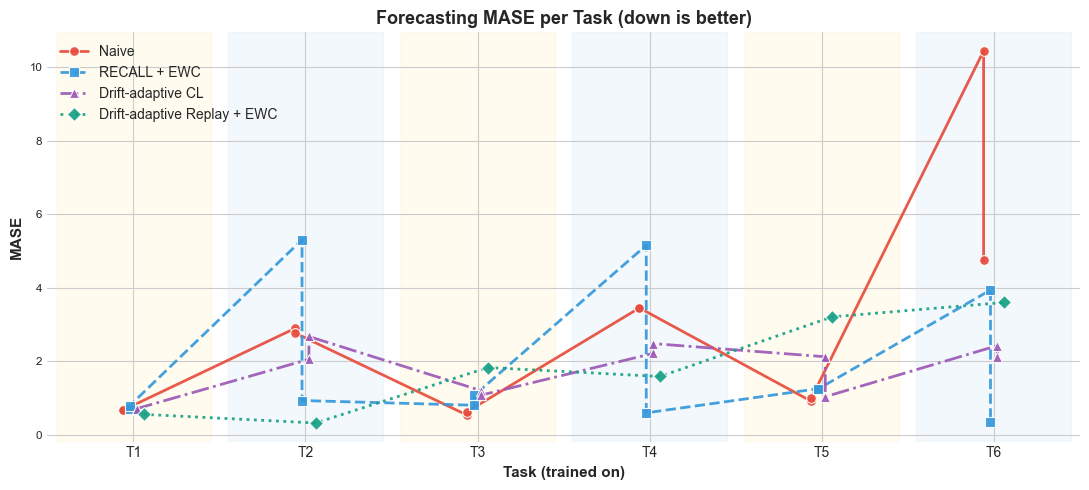

  Saved: 
C:\Users\Syakir\Downloads\Projects\fyp\outputs\hybrid\plots/mase_online_forecas
ting.png


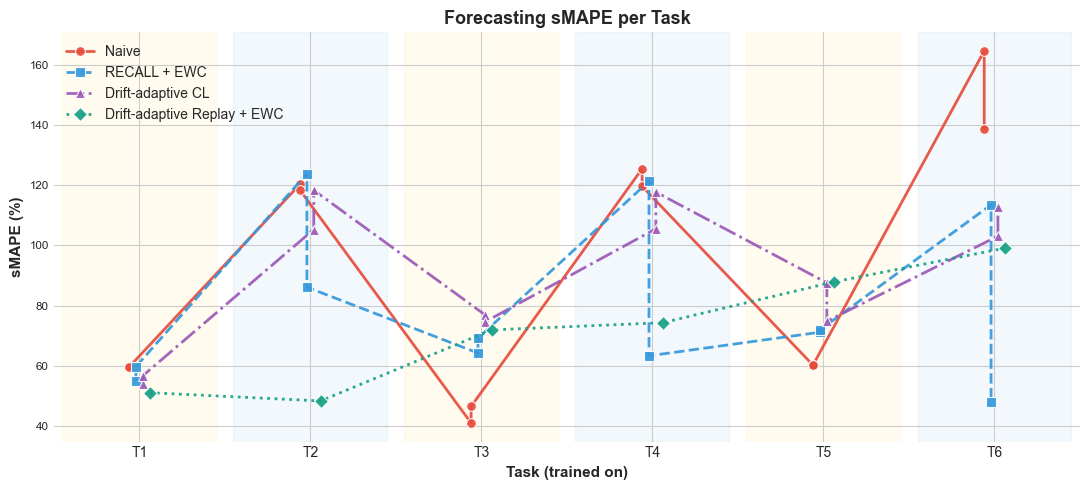

  Saved: 
C:\Users\Syakir\Downloads\Projects\fyp\outputs\hybrid\plots/smape_online_foreca
sting.png


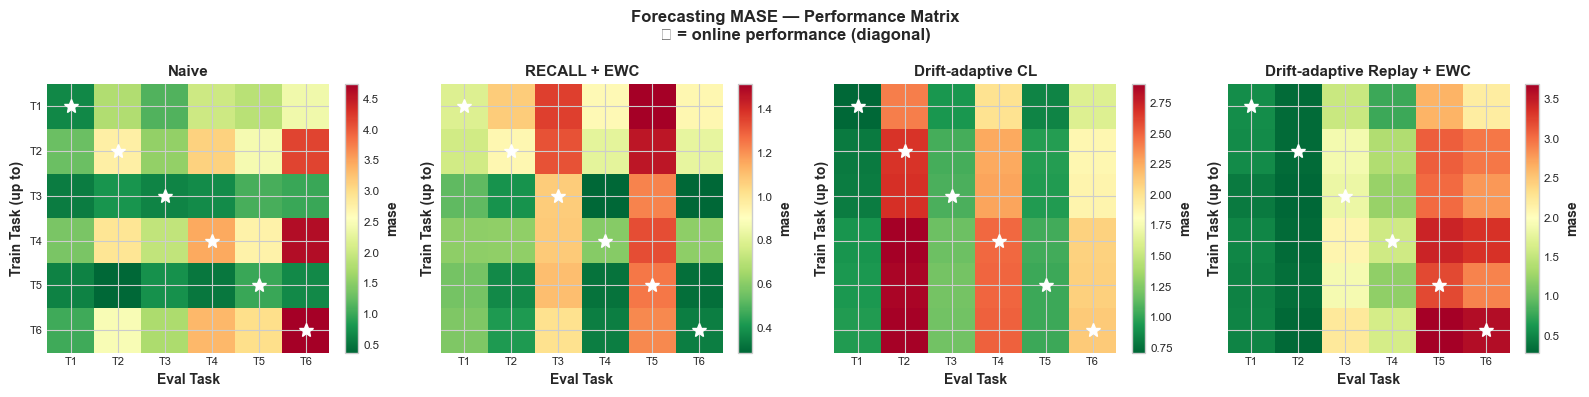

  Saved: 
C:\Users\Syakir\Downloads\Projects\fyp\outputs\hybrid\plots/perfmat_mase_foreca
sting.png


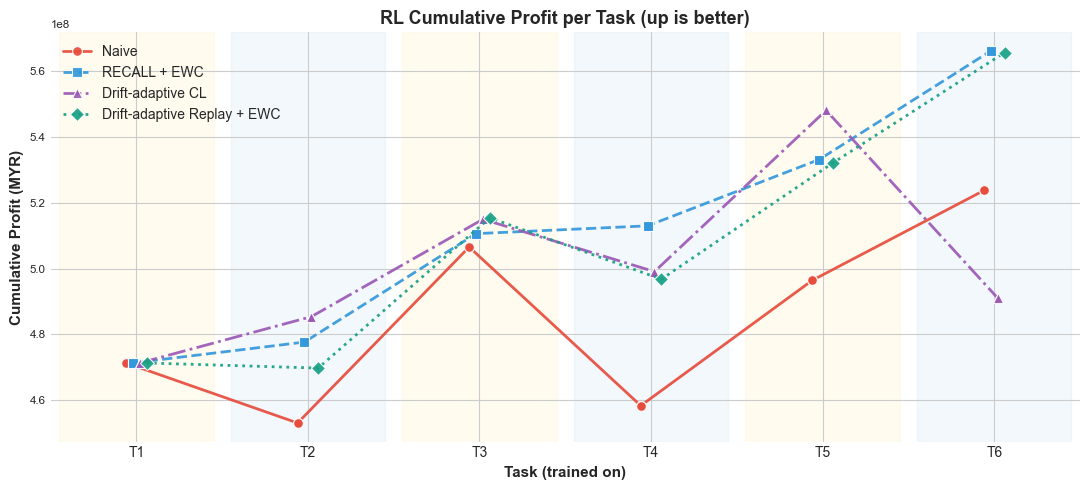

  Saved: 
C:\Users\Syakir\Downloads\Projects\fyp\outputs\hybrid\plots/profit_online_rl.pn
g


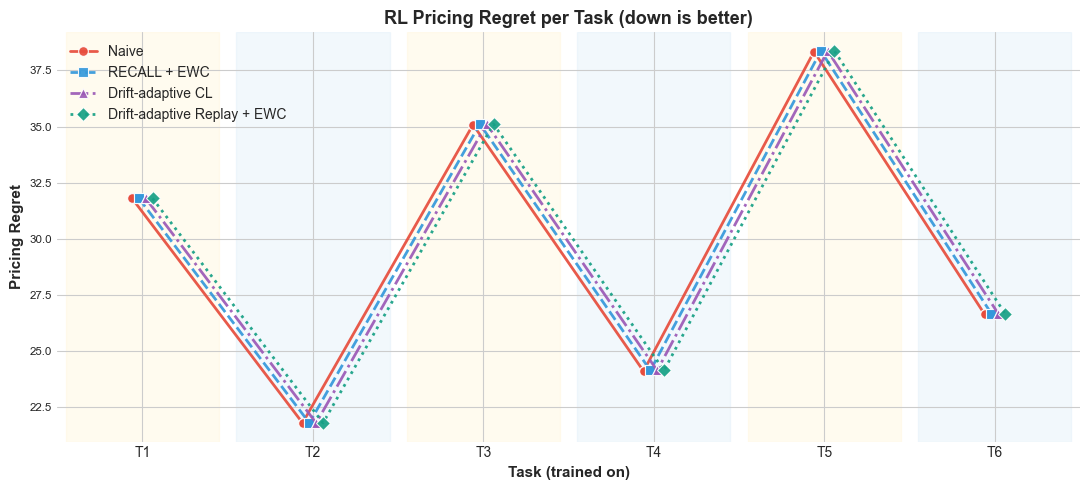

  Saved: 
C:\Users\Syakir\Downloads\Projects\fyp\outputs\hybrid\plots/regret_online_rl.pn
g


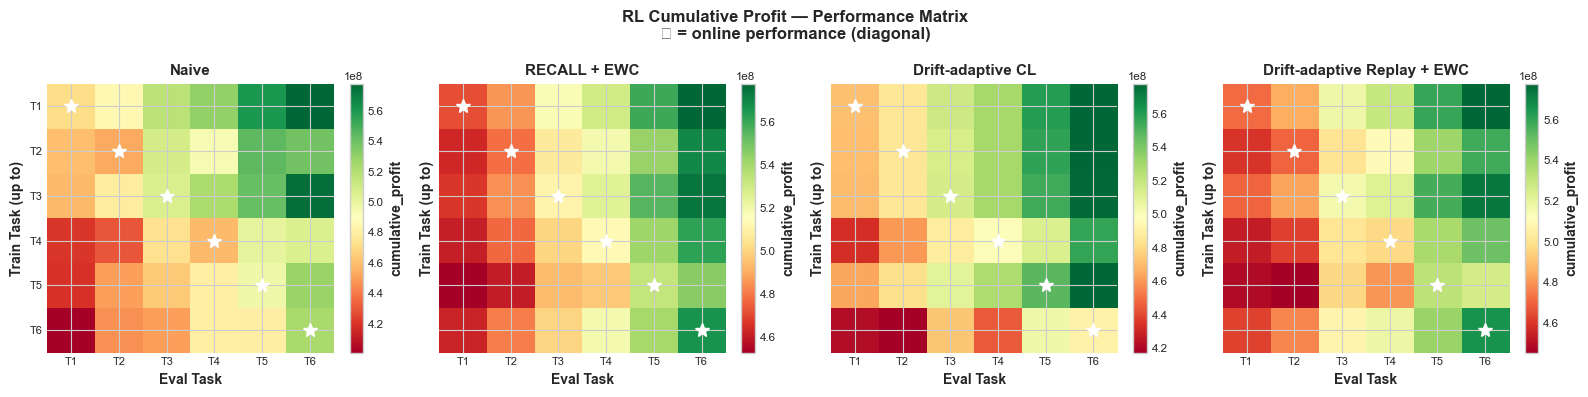

  Saved: 
C:\Users\Syakir\Downloads\Projects\fyp\outputs\hybrid\plots/perfmat_cumulative_
profit_rl.png


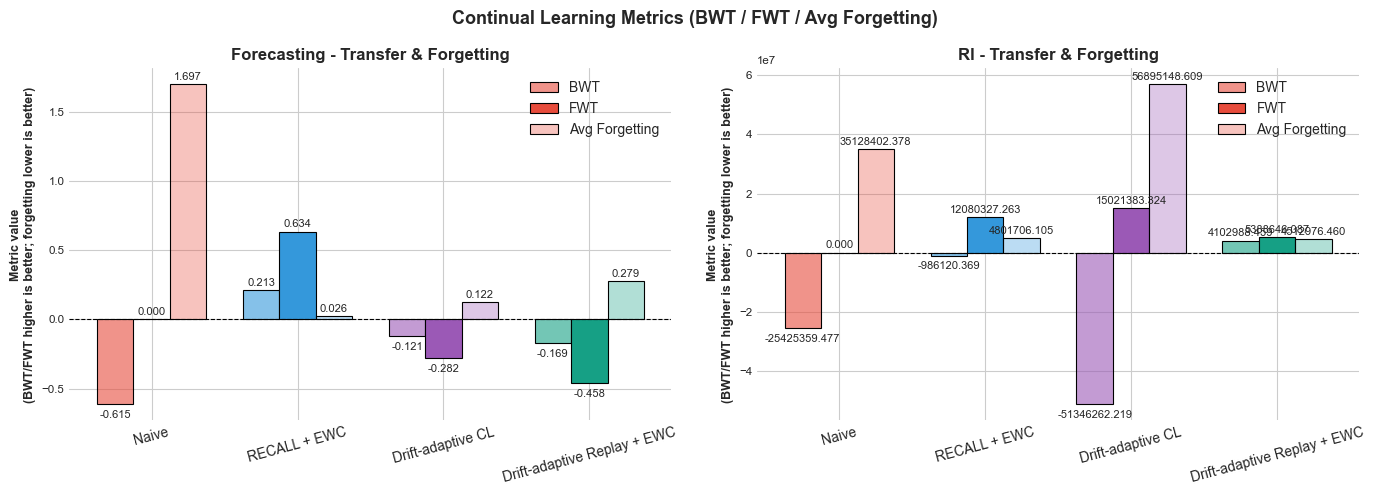

  Saved: 
C:\Users\Syakir\Downloads\Projects\fyp\outputs\hybrid\plots/cl_transfer_forgett
ing_comparison.png


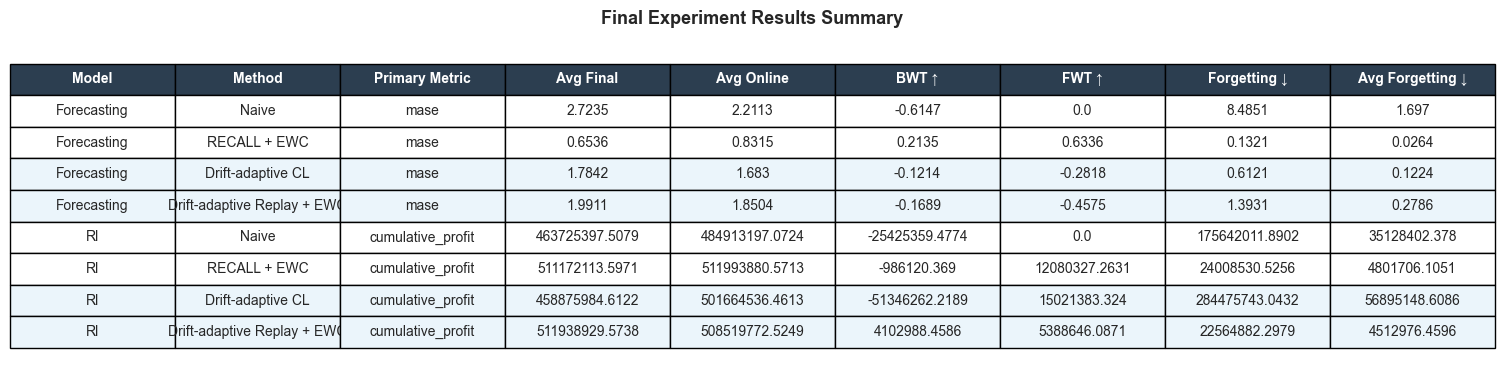

  Saved: 
C:\Users\Syakir\Downloads\Projects\fyp\outputs\hybrid\plots/final_summary_table
.png
All plots saved to plots/


,model_type,cl_method,primary_metric,avg_final_perf,avg_online_perf,bwt,fwt,forgetting,avg_forgetting
0,forecasting,naive,mase,2.723500e+00,2.211300e+00,-6.147000e-01,0.000000e+00,8.485100e+00,1.697000e+00
1,forecasting,recall_ewc,mase,6.536000e-01,8.315000e-01,2.135000e-01,6.336000e-01,1.321000e-01,2.640000e-02
2,forecasting,adaptive_drift,mase,1.784200e+00,1.683000e+00,-1.214000e-01,-2.818000e-01,6.121000e-01,1.224000e-01
3,forecasting,drift_adaptive_replay_ewc,mase,1.991100e+00,1.850400e+00,-1.689000e-01,-4.575000e-01,1.393100e+00,2.786000e-01
4,rl,naive,cumulative_profit,4.637254e+08,4.849132e+08,-2.542536e+07,0.000000e+00,1.756420e+08,3.512840e+07
5,rl,recall_ewc,cumulative_profit,5.111721e+08,5.119939e+08,-9.861204e+05,1.208033e+07,2.400853e+07,4.801706e+06
6,rl,adaptive_drift,cumulative_profit,4.588760e+08,5.016645e+08,-5.134626e+07,1.502138e+07,2.844757e+08,5.689515e+07
7,rl,drift_adaptive_replay_ewc,cumulative_profit,5.119389e+08,5.085198e+08,4.102988e+06,5.388646e+06,2.256488e+07,4.512976e+06


In [23]:
generate_all_plots(cl_summary)
